# Theoretical Quasinormal Excitation Coefficients (QNECs) in black hole ringdown

In this notebook we compute the excitation coefficients $C_n$ of quasi-normal modes (QNMs) for a Schwarzschild black hole using Gaussian initial data.

We consider two families of perturbations:

- A simple Gaussian pulse
- An oscillating Gaussian pulse

The goal is to study how the excitation of QNMs depends on the properties of the initial perturbation and to compare:

- the full Leaver projection
- the asymptotic approximation

In [11]:
import numpy as np
import matplotlib.pyplot as plt

import rw_solver as rw

# Initial data

We consider Gaussian initial data of the form

$$
f(s)
=
A
\exp\left[
-\frac{(s-r_0)^2}{2\sigma^2}
\right]
\cos\left[
\omega_0 (s-r_0)
\right]
$$

where:

- $A$ is the amplitude
- $r_0$ is the position of the perturbation
- $\sigma$ controls the spatial width
- $\omega_0$ introduces an oscillatory modulation

Two important cases are considered:

- $\omega_0 = 0$ → pure Gaussian pulse
- $\omega_0 \neq 0$ → oscillating Gaussian pulse

In [12]:
# ============================================================
# PARAMETERS
# ============================================================

A_init = 1.0

r0 = 100.0

l_mode = 2

Mbh = 1.0

global_fac = -2.0

nsigma_pad = 10.0

Nmax = 300

e_spin = 3.0

r_obs_target = 100

# ============================================================
# QNM FREQUENCIES
# ============================================================

omegas = np.array([
    0.3736716844180416 - 0.08896231568893692j,
    0.34671099687916285 - 0.27391487529123504j,
    0.30105345461250427 - 0.47827698322307044j,
    0.25150496222643026 - 0.7051482024421033j,
], dtype=complex)

# ============================================================
# LEAVER EXCITATION FACTORS
# ============================================================

B_list = np.array([
    1.269024e-1 + 2.031517e-2j,
    4.768259e-2 - 2.237546e-1j,
    -1.902843e-1 + 1.574857e-2j,
    8.086762e-2 + 7.961260e-2j,
], dtype=complex)

N_modes = len(B_list)

# Numerical setup

We first evolve a reference waveform numerically in order to define a common temporal frame for the QNM excitation coefficients.

The reference time is extracted from the arrival time of the dominant ringdown peak at the observer location.

In [13]:
# ============================================================
# NUMERICAL GRID
# ============================================================

sigma_ref_sigma = 1.0

w0_ref_sigma = 0.0

x_min, x_max = -200, 1000

Ngrid = 8000

TF = 500.0

# ============================================================
# INITIAL DATA
# ============================================================

Psi0 = rw.gaussiana(
    A_init,
    x_min,
    x_max,
    Ngrid,
    w0_ref_sigma,
    r0,
    sigma_ref_sigma
)

# ============================================================
# NUMERICAL EVOLUTION
# ============================================================

U, T, s = rw.simula_full(
    N=Ngrid,
    x_min=x_min,
    x_max=x_max,
    Psi_initial=Psi0,
    TF=TF,
    CFL=0.1,
    l=l_mode,
    M=Mbh
)

s = np.array(s, float)

ds = s[1] - s[0]

r_areal = rw.r_of_s(s, M=Mbh)

r_obs_areal = rw.r_of_s(
    np.array([r_obs_target]),
    M=Mbh
)[0]

# Reference ringdown time — σ sweep

To compare all excitation coefficients consistently across the $\sigma$ sweep, we define a common temporal reference frame.

The reference time is extracted from the peak of the numerical waveform measured at the observer position.

In [14]:
# ============================================================
# REFERENCE RINGDOWN TIME — SIGMA SWEEP
# ============================================================

idx_obs = np.argmin(
    np.abs(s - r_obs_target)
)

Psi_obs = U[:, idx_obs]

mask_peak = (
    (T >= 195.0)
    &
    (T <= 205.0)
)

T_search = T[mask_peak]

Psi_search = np.abs(
    Psi_obs[mask_peak]
)

idx_peak = np.argmax(Psi_search)

t_peak_ref_sigma = T_search[idx_peak]

print(
    f"t_peak_ref_sigma = "
    f"{t_peak_ref_sigma:.6f}"
)

t_peak_ref_sigma = 201.295162


# Leaver's method

The QNM radial functions are constructed using Leaver’s method.

The perturbations satisfy the Regge–Wheeler equation

$$
\frac{d^2\psi}{ds^2}
+
\left(
\omega^2 - V(s)
\right)\psi
=
0.
$$

Leaver’s method expands the solution as a power series:

$$
\psi(r)
=
z^{2p}
\sum_{n=0}^{\infty}
a_n z^n,
$$

where

$$
z = 1 - \frac{1}{r},
\qquad
p = -2 i M \omega.
$$

The coefficients satisfy a three-term recurrence relation which is solved numerically using backward recursion (Miller algorithm).

The resulting solution automatically satisfies the quasi-normal mode boundary conditions:

- purely ingoing at the horizon
- purely outgoing at infinity

In [15]:
def leaver_an_coeffs(
    omega,
    l,
    M=1.0,
    e=e_spin,
    Nmax=300
):

    omega_bar = 2.0 * M * complex(omega)

    p = -1j * omega_bar

    def alpha(n):
        return (
            n*n
            + (2*p + 2)*n
            + (2*p + 1)
        )

    def beta(n):
        return -(
            2*n*n
            + (8*p + 2)*n
            + 8*p*p
            + 4*p
            + l*(l+1)
            - e
        )

    def gamma(n):
        return (
            n*n
            + 4*p*n
            + 4*p*p
            - e
            - 1
        )

    a = np.zeros(
        Nmax + 2,
        dtype=complex
    )

    a[Nmax] = 1.0

    for n in range(Nmax, 0, -1):

        a[n-1] = -(
            beta(n)*a[n]
            + alpha(n)*a[n+1]
        ) / gamma(n)

    return a[:Nmax+1] / a[0]


def psi_leaver_norm(
    omega,
    r_areal
):

    r_bar = np.asarray(r_areal) / (2*Mbh)

    z = 1.0 - 1.0/r_bar

    a = leaver_an_coeffs(
        omega,
        l_mode,
        Mbh
    )

    Sz = np.zeros_like(
        z,
        dtype=complex
    )

    for an in a[::-1]:
        Sz = Sz*z + an

    S1 = np.sum(a)

    p = -1j * (2*Mbh*omega)

    return (
        np.exp((2*p)*np.log(z))
        * (Sz / S1)
    )

# Excitation coefficients

The excitation of each QNM is determined through the overlap integral

$$
I_n
=
\int ds\,
e^{i\omega_n s}
\psi_n(s)
q(s),
$$

where

$$
q(s)
=
i\omega_n f(s)
-
g(s).
$$

For comparison, we also consider the asymptotic approximation

$$
\psi_n(s)\approx 1,
$$

leading to

$$
I_n^{\rm asy}
=
\int ds\,
e^{i\omega_n s}
q(s).
$$

The excitation coefficients are then constructed as

$$
C_n
=
\mathcal N
B_n
\psi_n(r_{\rm obs})
I_n
e^{-i\omega_n(t_{\rm ref}-r_0)}.
$$

The temporal phase factor aligns all coefficients to a common ringdown reference frame extracted from the numerical simulations.

In [16]:
def build_initial_data(
    sigma,
    w0
):

    f = (
        A_init
        * np.exp(
            -(s - r0)**2
            / (2 * sigma**2)
        )
        * np.cos(
            w0 * (s - r0)
        )
    )

    g = rw.d1_4th(f, ds)

    mask = (
        (s >= r0 - nsigma_pad*sigma)
        &
        (s <= r0 + nsigma_pad*sigma)
    )

    return (
        s[mask],
        r_areal[mask],
        f[mask],
        g[mask]
    )


def compute_Cn_for_pulse(
    sigma,
    w0,
    t_ref
):

    C_exact = np.zeros(
        N_modes,
        dtype=complex
    )

    C_asy = np.zeros(
        N_modes,
        dtype=complex
    )

    s_int, r_int, f_int, g_int = \
        build_initial_data(
            sigma,
            w0
        )

    for n, om in enumerate(omegas):

        q = (
            1j * om * f_int
            - g_int
        )

        psi_int = psi_leaver_norm(
            om,
            r_int
        )

        psi_obs = psi_leaver_norm(
            om,
            [r_obs_areal]
        )[0]

        exp_term = np.exp(
            1j * om * s_int
        )

        I_exact = np.trapz(
            exp_term * psi_int * q,
            s_int
        )

        I_asy = np.trapz(
            exp_term * q,
            s_int
        )

        phase = np.exp(
            -1j * om * (t_ref - r0)
        )

        C_exact[n] = (
            global_fac
            * B_list[n]
            * psi_obs
            * I_exact
            * phase
        )

        C_asy[n] = (
            global_fac
            * B_list[n]
            * I_asy
            * phase
        )

    return C_exact, C_asy

# Gaussian pulse (σ sweep)

We first study the dependence of the excitation coefficients on the Gaussian width $\sigma$ while keeping $\omega_0=0$ fixed.

In [ ]:
sigma_values = np.arange(
    0.01,
    10.0,
    0.01
)

C_exact_sigma = np.zeros(
    (len(sigma_values), N_modes),
    dtype=complex
)

C_asy_sigma = np.zeros_like(
    C_exact_sigma
)

for i, sigma in enumerate(sigma_values):

    C_exact_sigma[i], C_asy_sigma[i] = \
        compute_Cn_for_pulse(
            sigma,
            0.0,
            t_peak_ref_sigma
        )

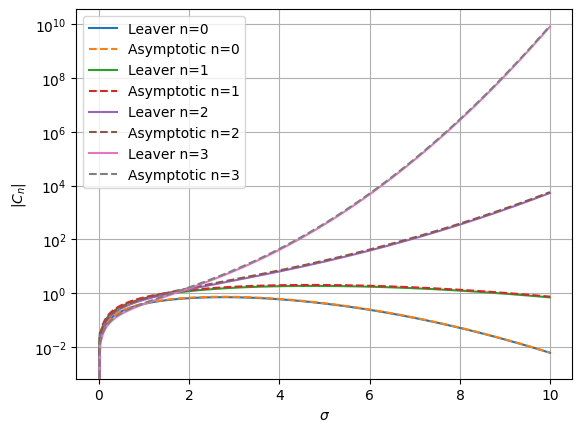

In [18]:
plt.figure()

for n in range(4):

    plt.plot(
        sigma_values,
        np.abs(C_exact_sigma[:, n]),
        label=f"Leaver n={n}"
    )

    plt.plot(
        sigma_values,
        np.abs(C_asy_sigma[:, n]),
        "--",
        label=f"Asymptotic n={n}"
    )

plt.yscale("log")

plt.xlabel(r"$\sigma$")
plt.ylabel(r"$|C_n|$")

plt.legend()

plt.grid(True)

plt.show()

# Reference ringdown time — ν sweep

For the frequency sweep we define a separate temporal reference frame using a representative oscillating Gaussian pulse with fixed width $\sigma=5$.

In [19]:
sigma_ref_nu = 5.0

w0_ref_nu = 0.0

Psi0_nu = rw.gaussiana(
    A_init,
    x_min,
    x_max,
    Ngrid,
    w0_ref_nu,
    r0,
    sigma_ref_nu
)

U_nu, T_nu, s_nu = rw.simula_full(
    N=Ngrid,
    x_min=x_min,
    x_max=x_max,
    Psi_initial=Psi0_nu,
    TF=TF,
    CFL=0.1,
    l=l_mode,
    M=Mbh
)

idx_obs_nu = np.argmin(
    np.abs(s_nu - r_obs_target)
)

Psi_obs_nu = U_nu[:, idx_obs_nu]

mask_peak_nu = (
    (T_nu >= 195.0)
    &
    (T_nu <= 205.0)
)

T_search_nu = T_nu[mask_peak_nu]

Psi_search_nu = np.abs(
    Psi_obs_nu[mask_peak_nu]
)

idx_peak_nu = np.argmax(
    Psi_search_nu
)

t_peak_ref_nu = T_search_nu[idx_peak_nu]

print(
    f"t_peak_ref_nu = "
    f"{t_peak_ref_nu:.6f}"
)

t_peak_ref_nu = 199.989999


# Oscillating Gaussian pulse (frequency sweep)

We now fix $\sigma=5$ and vary the oscillation frequency $\nu$ of the initial perturbation.

In [20]:
sigma = 5.0

w0_values = np.arange(
    0.0,
    1.0,
    0.001
)

C_exact_freq = np.zeros(
    (len(w0_values), N_modes),
    dtype=complex
)

C_asy_freq = np.zeros_like(
    C_exact_freq
)

for i, w0 in enumerate(w0_values):

    C_exact_freq[i], C_asy_freq[i] = \
        compute_Cn_for_pulse(
            sigma,
            w0,
            t_peak_ref_nu
        )

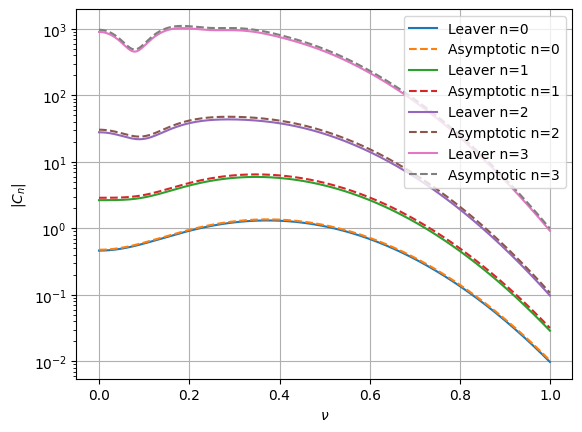

In [21]:
plt.figure()

for n in range(4):

    plt.plot(
        w0_values,
        np.abs(C_exact_freq[:, n]),
        label=f"Leaver n={n}"
    )

    plt.plot(
        w0_values,
        np.abs(C_asy_freq[:, n]),
        "--",
        label=f"Asymptotic n={n}"
    )

plt.yscale("log")

plt.xlabel(r"$\nu$")
plt.ylabel(r"$|C_n|$")

plt.legend()

plt.grid(True)

plt.show()